bivarite n2n visualizations

In [16]:
import pandas as pd

url = "https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/penguins_cleaned.csv"
df = pd.read_csv(url)
df.head(1)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,male


In [17]:
import scipy.stats as stats

In [38]:
r,p = stats.pearsonr(df["body_mass_g"], df["bill_length_mm"])
r2 = r**2


Text(0.5, 1.0, 'Correlation between Penguin Body Mass (g) to Bill Length')

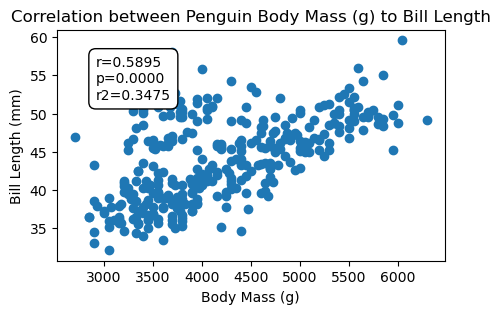

In [39]:
#create a scatter plot with matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize = (5,3))
text = f"""r={r:.4f}
p={p:.4f}
r2={r2:.4f}"""
plt.scatter(df["body_mass_g"], df["bill_length_mm"])
plt.xlabel("Body Mass (g)")
plt.ylabel("Bill Length (mm)")
plt.text(
    0.1,
    0.7,
    text,
    transform=plt.gca().transAxes,
    bbox={"boxstyle":"round, pad=0.5", "fc": "white"}
)
plt.title("Correlation between Penguin Body Mass (g) to Bill Length")

r of 0.58 is moderatly positive correlation. p of 0.000 means that our r value is significant and there is a low chance that this is a false posititve, reject null hypothesis. r means that 34% of the movement in y is determined by teh movement in x.

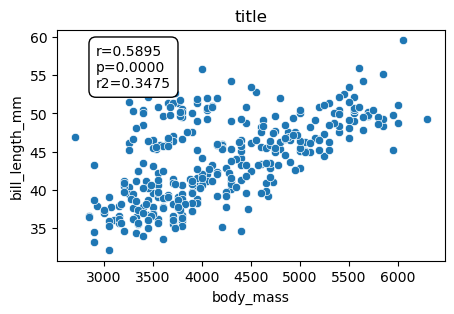

In [40]:
# do above with seaborn
import seaborn as sns

plt.figure(figsize=(5,3))
scat = sns.scatterplot(data=df, x="body_mass_g", y= "bill_length_mm") #varable because seaborn wants that
scat.text(
    0.1,
    0.75,
    text,
    transform=scat.transAxes,
    bbox={"boxstyle":"round, pad=0.5", "fc": "white"})
scat.set(xlabel="body_mass", title="title")
plt.show()
#dict(boxstyle="",)

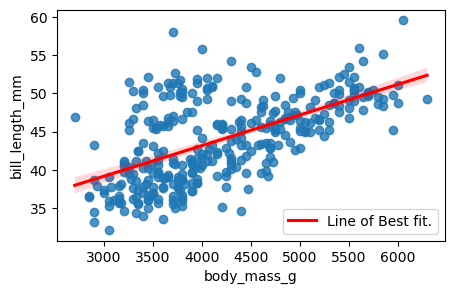

In [22]:
plt.figure(figsize=(5,3))
reg = sns.regplot(
    data=df,
    x="body_mass_g", 
    y= "bill_length_mm",
    line_kws={"color":"red","label": "Line of Best fit."}) #accepts dict
plt.legend()

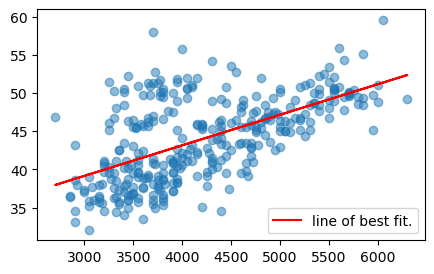

In [29]:
x = df["body_mass_g"]
y = df["bill_length_mm"]
m, b, r_val, p_val, err = stats.linregress(df["body_mass_g"], df["bill_length_mm"])
#gives slope = m, intercept = b, r =r, p = p, std.err = err
# plug into y = mx +b
line = m * df["body_mass_g"] + b

plt.figure(figsize= (5,3))
plt.scatter(x,y, alpha=0.5)
plt.plot(x, line, color="red", label = "line of best fit.") #add line
plt.legend()
plt.show()



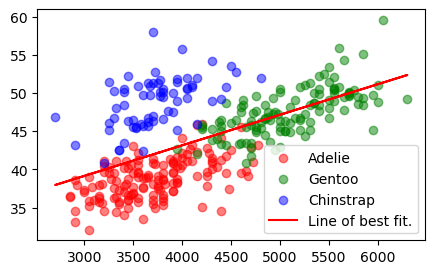

In [32]:
plt.figure(figsize=(5,3))
colors = ["red", "green", "blue"]
for species in df["species"].unique():
    subset = df.loc[df["species"] == species]
    x1 = subset["body_mass_g"]
    y1 = subset["bill_length_mm"]
    plt.scatter(x1,y1,alpha=0.5, label=species, color=colors.pop(0))
plt.plot(x, line, color="red", label="Line of best fit.")
plt.legend()
plt.show()

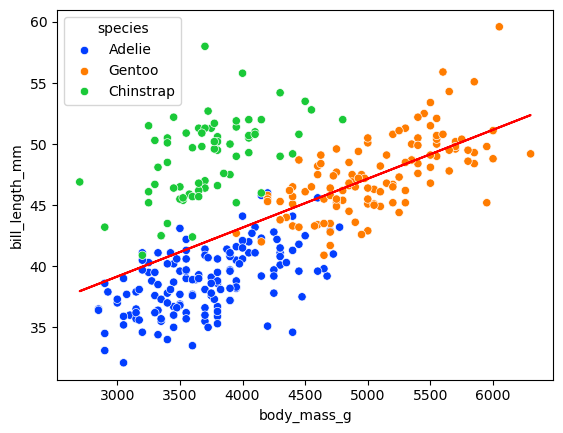

In [34]:
x_str = "body_mass_g"
y_str = "bill_length_mm"
scat = sns.scatterplot(
    data = df,
    x=x_str,
    y=y_str,
    hue="species",
    #palette="oragne","blue","green"
    palette="bright"
)
plt.plot(x, line, color="red")

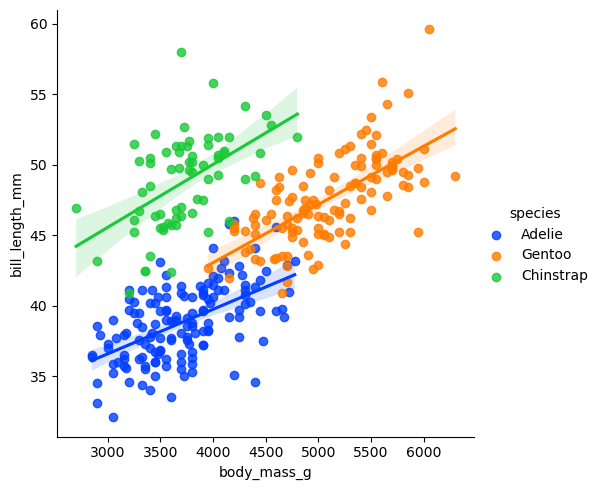

In [36]:
lm = sns.lmplot(
    data=df,
    x=x_str,
    y=y_str,
    hue="species",
    palette="bright",
)

<Figure size 500x300 with 0 Axes>

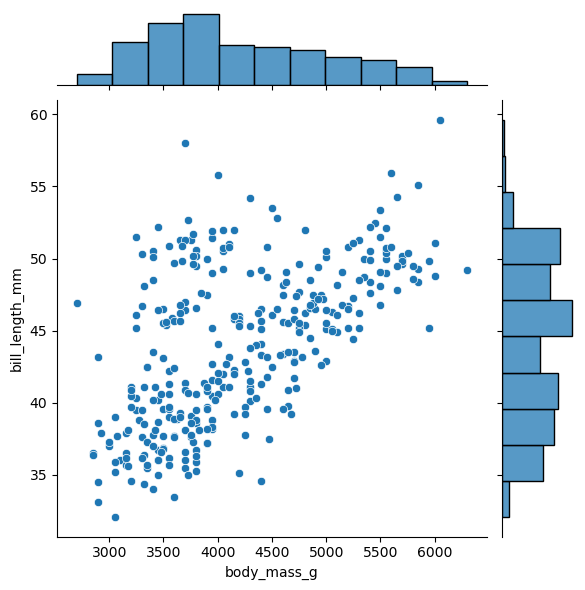

In [37]:
plt.figure(figsize=(5,3))
sns.jointplot(
    data=df,
    x=x_str,
    y=y_str,
)

can see distribution accross the axis